In [ ]:
# %conda install seaborn

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [14]:
mpg = sns.load_dataset("mpg")
mpg.info()
mpg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


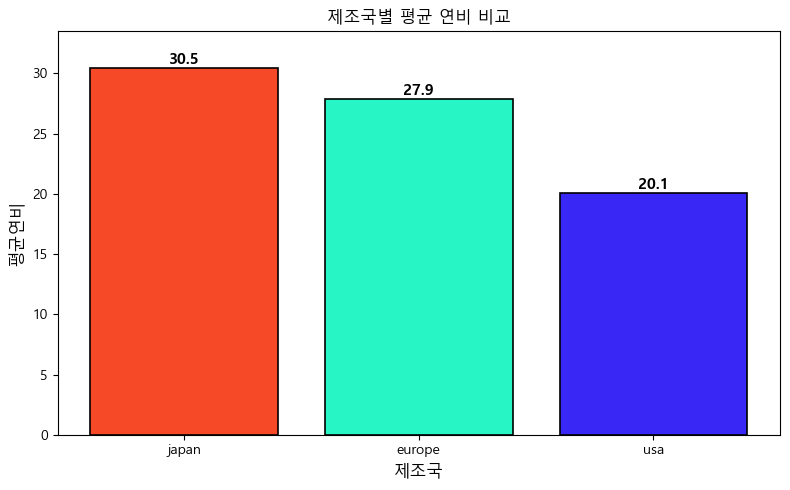

In [15]:
# 제조국(origin)별 평균 연비 mpg
origin_mpg = mpg.groupby('origin')['mpg'].mean().sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(8,5))

bars = ax.bar(origin_mpg.index, origin_mpg.values,color=['#F54927','#27F5C5','#3827F5'],
       edgecolor = 'black', linewidth=1.2)


# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, 
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('제조국',fontsize=12)
ax.set_ylabel('평균연비',fontsize=12)
ax.set_title('제조국별 평균 연비 비교')
ax.set_ylim(0, origin_mpg.max()*1.1)
plt.tight_layout()
plt.show()


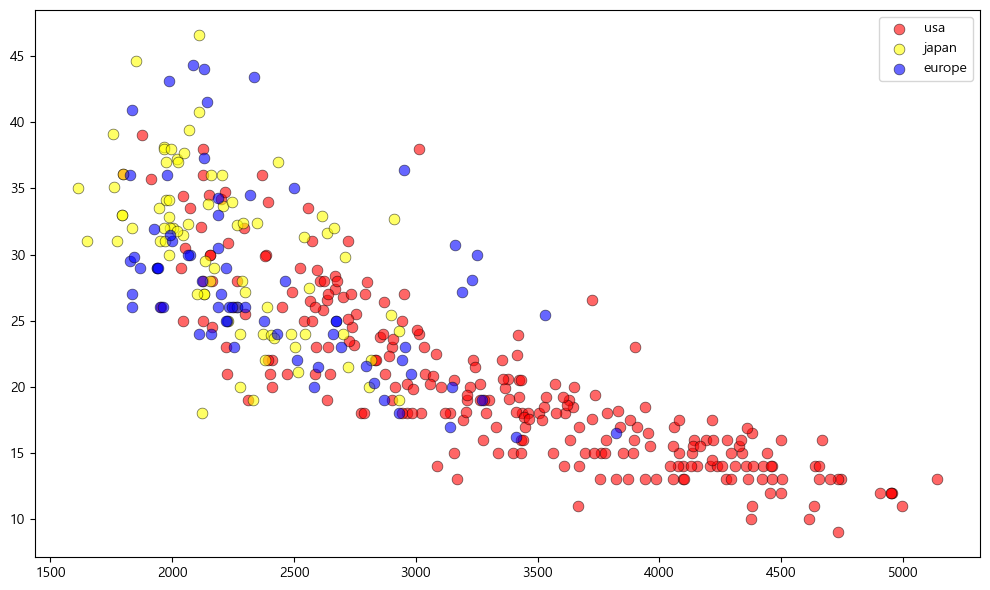

In [16]:
from matplotlib import pyplot as plt

fig , ax = plt.subplots(figsize=(10, 6))
new_mpg = mpg.sort_values(by=['weight'])[['weight','mpg']]
#ax.scatter(new_mpg['weight'],new_mpg['mpg'])

color = {'usa' : 'red' , 'japan' : 'yellow' , 'europe' : 'blue'}
for origin , color in color.items():
    mask = mpg['origin'] == origin
    ax.scatter(mpg[mask]['weight'] , mpg[mask]['mpg'] , c=color ,label=origin,
               alpha=0.6,s=60,edgecolors='black',linewidths=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [18]:
mpg = sns.load_dataset('mpg')
print(f'전체 데이터 {len(mpg)}')
mpg.describe()

전체 데이터 398


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


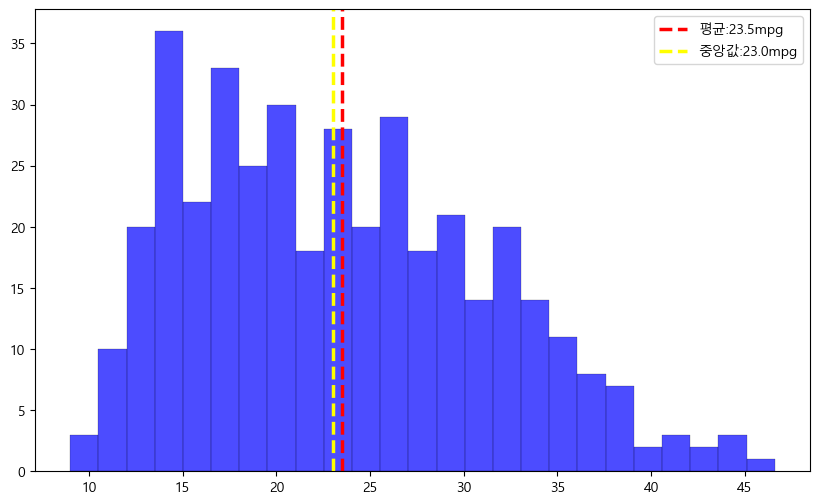

In [19]:
#연비는 정규분포를 따를까?
# histogram
fig,ax = plt.subplots(figsize=(10,6))
n , bins, patches =  ax.hist(mpg['mpg'],bins=25,edgecolor='black', color='blue',alpha=0.7,linewidth=0.2)
# 평균선 추가
mean_mpg = mpg['mpg'].mean()
ax.axvline(mean_mpg,color='red',linestyle='--',linewidth=2.5,label=f'평균:{mean_mpg:.1f}mpg')
# 중앙선
median_mpg = mpg['mpg'].median()
ax.axvline(median_mpg,color='yellow',linestyle='--',linewidth=2.5,label=f'중앙값:{median_mpg:.1f}mpg')

ax.legend()

# 정규분포는 대칭성  
# 평균 = 중앙값 = 최빈값
# 좌우가 대칭인종모양
# 평균 > 중앙값 - > 우측꼬리가 존재(고연비차량이 존재)  --> 정규분포 아님
# 10 ~20 에집붕... -> 저연비 차량 비중이 높다

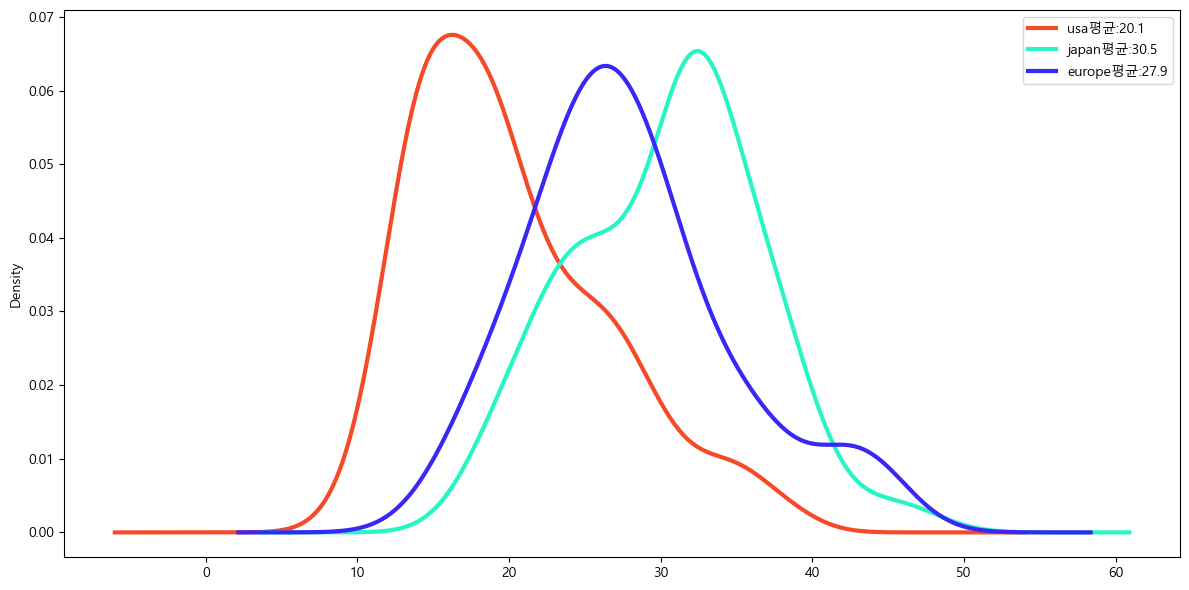

In [20]:
# 밀도... 부드러운 분포곡선
# 국가별 연비 분포
colors = {
'usa':'#F54927',
'japan':'#27F5C5',
'europe':'#3827F5'
}
fig, ax = plt.subplots(figsize=(12,6))
for origin, color in colors.items():
    data = mpg['origin'] == origin
    data = mpg[data]['mpg']
    data.plot.kde(ax=ax,color=color,linewidth=3, label=f'{origin}평균:{data.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()    

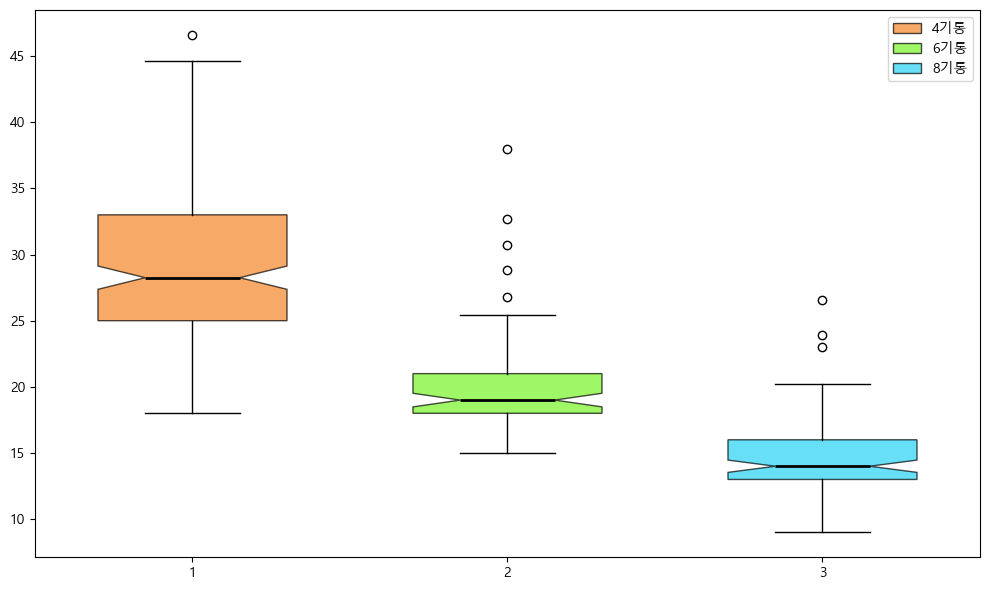

4기통 - 중앙값:28.2 IQR:8.0            이상치개수 : 1
6기통 - 중앙값:19.0 IQR:3.0            이상치개수 : 5
8기통 - 중앙값:14.0 IQR:3.0            이상치개수 : 3


In [25]:
# boxplot : 이상치, 사분위수
# 실린더 수별로 연비편차가 얼마나 다를까?
fig, ax = plt.subplots(figsize=(10,6))
mpg_clean =  mpg[mpg['cylinders'].isin([4,6,8])].copy()

box_data = [  mpg_clean[mpg_clean['cylinders'] == cyl]['mpg']  for cyl in [4,6,8]]
bp = ax.boxplot(box_data,label=['4기통','6기통','8기통'],patch_artist=True,notch=True,widths=0.6)

# box색상
colors = ['#F58727','#76F527','#27D3F5']
for patch,color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.legend()    

# 중강값선 강조
for median in bp['medians']:
    median.set(color='black', linewidth=2)

plt.tight_layout()
plt.show()

# 통계요약
for cyl in [4,6,8]:
    data = mpg_clean[mpg_clean['cylinders'] == cyl]['mpg']
    q1,q3 = data.quantile([0.25,0.75])
    iqr = q3-q1
    print(f'{cyl}기통 - 중앙값:{data.median():.1f} IQR:{iqr:.1f} \
           이상치개수 : { len(data[(data > q3+1.5*iqr) | (data < q1 - 1.5*iqr)] ) }' )

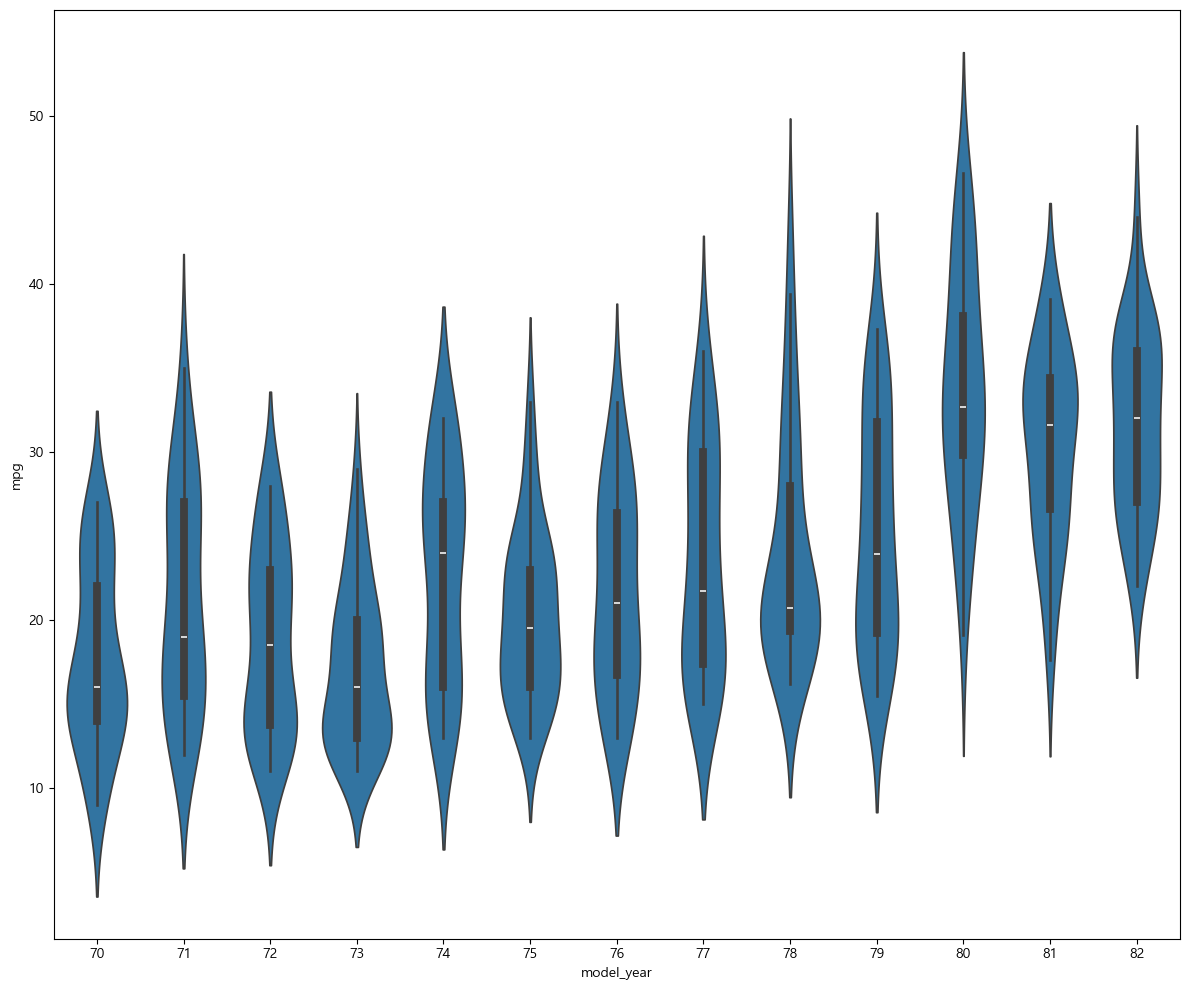

In [34]:
import matplotlib.pyplot as plt
# violineplot 분포형태
# 연식에 따라 연비분포가 어떻게 진화했는가 ?
fig, ax = plt.subplots(figsize=(12,10))
sns.violinplot(data=mpg , x='model_year' , y='mpg' , ax=ax)
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14152\220359536.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])


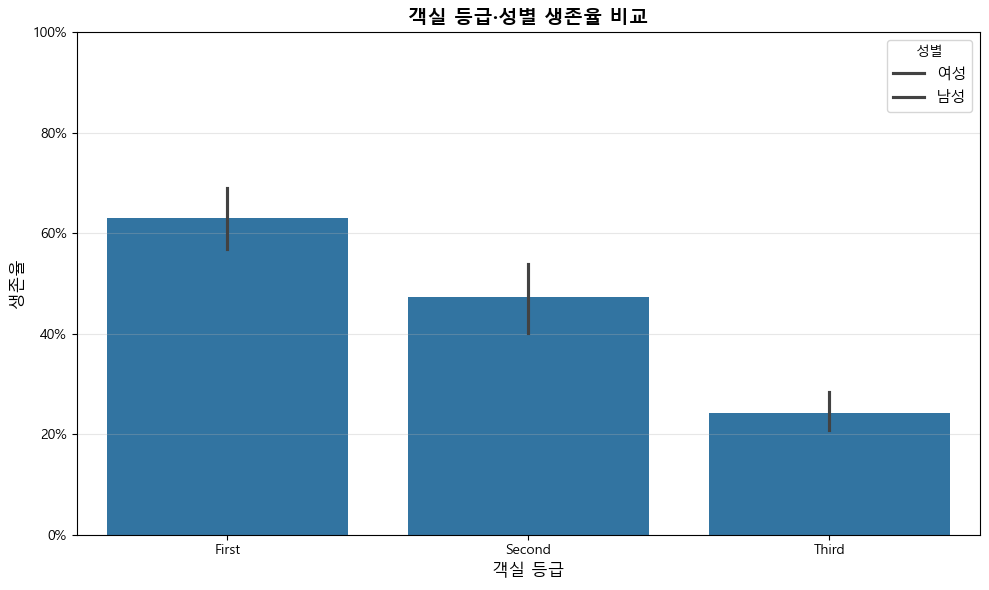

class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14152\220359536.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
titanic = sns.load_dataset('titanic')
# Barplot with hue
sns.barplot(data=titanic,x='class' , y='survived')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title('객실 등급·성별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='성별', labels=['여성', '남성'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Y축을 백분율로 표시
ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()

# 통계 확인
survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()
print(survival_by_class_sex)
#  인사이트: 1등급 여성 생존율 96.8% vs 3등급 남성 13.5% → 23배 차이
#  '여성과 어린이 먼저' 원칙이 1등급에서 더 철저히 적용됨

In [43]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14152\1970922605.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])


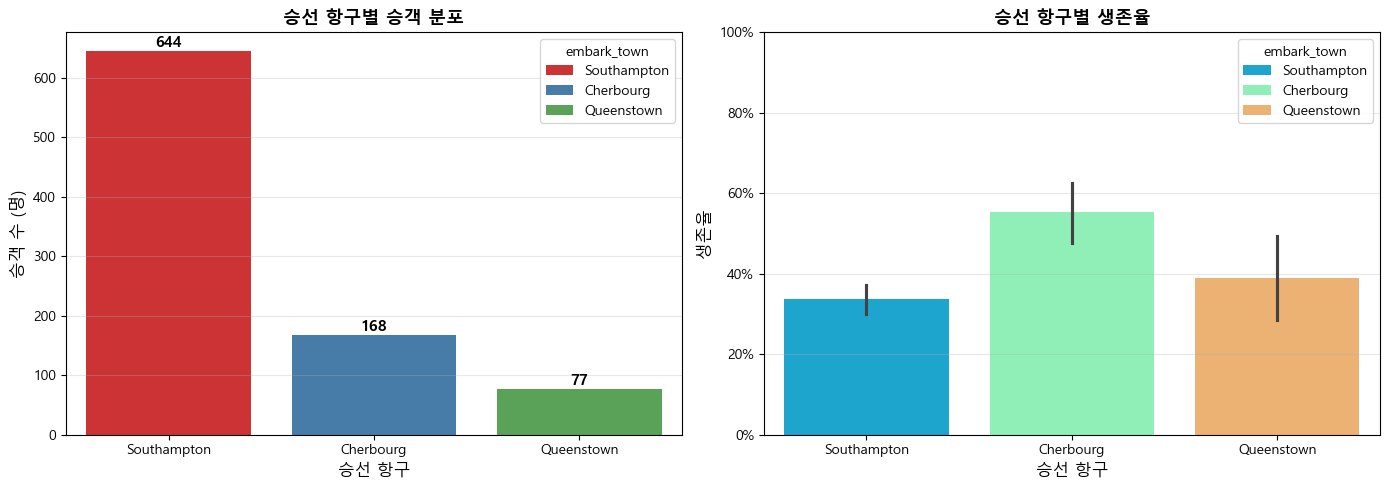

            survived           
                mean  sum count
embark_town                    
Cherbourg      0.554   93   168
Queenstown     0.390   30    77
Southampton    0.337  217   644


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 항구별 승객 수
sns.countplot(data=titanic , x= 'embark_town' , ax=axes[0] , palette='Set1' , hue='embark_town')

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

axes[0].set_xlabel('승선 항구', fontsize=12)
axes[0].set_ylabel('승객 수 (명)', fontsize=12)
axes[0].set_title('승선 항구별 승객 분포', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 우측: 항구별 생존율
sns.barplot(data=titanic , x= 'embark_town' , y='survived' , ax=axes[1] ,palette='rainbow' , hue='embark_town')

axes[1].set_xlabel('승선 항구', fontsize=12)
axes[1].set_ylabel('생존율', fontsize=12)
axes[1].set_title('승선 항구별 생존율', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 상세 분석
embark_stats = titanic.groupby('embark_town').agg({
    'survived': ['mean', 'sum', 'count']
}).round(3)
print(embark_stats)

#  인사이트: Cherbourg 승선객이 생존율 55% (Southampton 34% 대비 1.6배)
#  Cherbourg는 1등급 비율 높음 → 등급이 생존율 차이의 주요 변수

In [ ]:
# 각 범주형 변수별 생존율 계산
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df = factors_df.sort_values('생존율', ascending=False)
factors_df




#  인사이트: 성별이 가장 강력한 요인 (여성 74% vs 남성 19%)
#  등급도 중요하지만 성별만큼 극명하지는 않음
#  어린이 우대 정책도 효과적 (59% 생존)



,요인,생존율
0,성별(여성),0.742038
2,1등급,0.629630
4,어린이(<10세),0.612903
5,성인(30-50세),0.417969
3,3등급,0.242363
1,성별(남성),0.188908


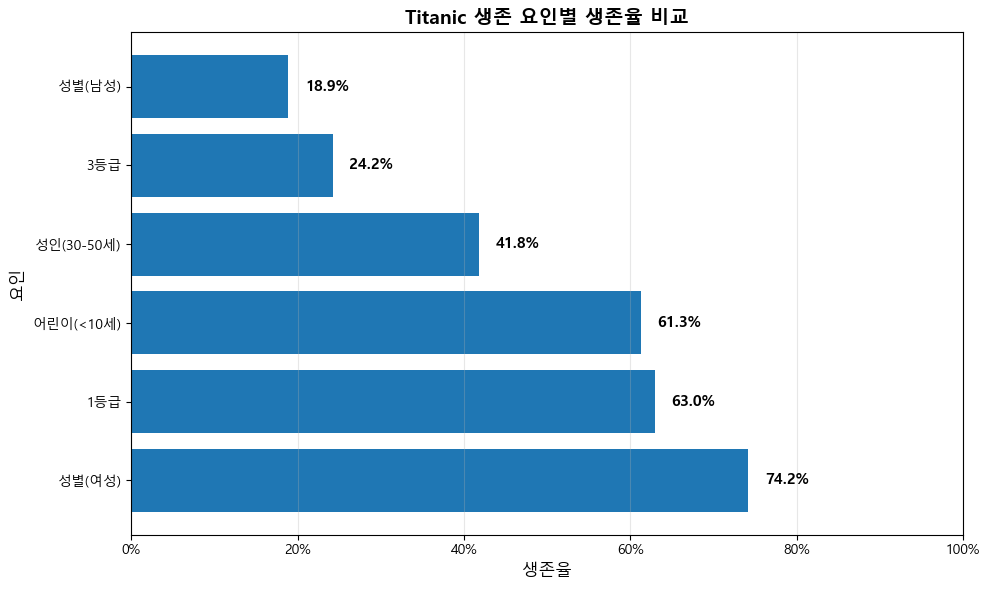

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(factors_df['요인'] , factors_df['생존율'])
# 수치 표시
for i, (factor, rate) in enumerate(zip(factors_df['요인'], factors_df['생존율'])):
    ax.text(rate + 0.02, i, f'{rate*100:.1f}%', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('생존율', fontsize=12)
ax.set_ylabel('요인', fontsize=12)
ax.set_title('Titanic 생존 요인별 생존율 비교', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()